# <center> Logistic regression on real data
    
Authors: Rémi LELUC and François PORTIER

### Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from models import logisticReg
from sklearn.linear_model import LogisticRegression
from simus import run_log
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
from tqdm.notebook import tqdm
from sklearn.datasets import load_svmlight_file
# to transform sparse matrix into numpy arrays
from scipy.sparse import csr_matrix
def load_data(filename):
    S,y = load_svmlight_file(f=filename)
    X = csr_matrix.toarray(S)
    return X,y

### Load datasets

In [2]:
#X,y = load_data('datasets_LIBSVM/mushrooms')
#y[y==2]=-1 # for mushrooms dataset

X,y = load_data('datasets_LIBSVM/phishing')
y[y==0]=-1 # for phishing dataset

scaler = StandardScaler()
X = scaler.fit_transform(X)
print(X.shape)
print(np.unique(y,return_counts=True))
n_samples,n_features = X.shape

(11055, 68)
(array([-1.,  1.]), array([4898, 6157]))


### Compute optimal $\theta^\star$

In [3]:
𝜆 = 1/n_samples          #regularization parameter
c_reg = 1/(n_samples*λ)
log_sk = LogisticRegression(C=c_reg,fit_intercept=False,tol=1e-3)
# fit sklearn model
log_sk.fit(X=X,y=y)
coeff = log_sk.coef_[0]

In [4]:
data_term  = np.log(1+np.exp(np.multiply(-y,X@coeff))).mean()
reg_term = (𝜆/2)*sum(coeff**2)
print('data_term:',data_term)
print('reg_term :',reg_term)
# Optimal loss
log = logisticReg(X=X,y=y,λ=λ,fit_intercept=False)
loss_opt = log.loss(w=coeff)
print('loss_opt :',loss_opt)

data_term: 0.14241398466545105
reg_term : 0.0005437180698045692
loss_opt : 0.14295770273525563


## Parameter simulations

In [5]:
## Parameter Configuration for Mushroom dataset
#N = int(2e2)   
#N_exp = 30      
#lr = 0.6       
#k0 = 15
#alpha_power = 1  
#batch_size= 16   
#batch_hess= 64
#c=1
#power =1/2
#𝜂 = 1
#same=False

In [6]:
## Parameter Configuration for Phishing dataset
N = int(2e2)   
N_exp = 30     
lr = 0.5       
k0 = 20
alpha_power = 1 
batch_size= 16  
batch_hess= 64
c=0.1
power =1/2
𝜂 = 1
same=False

### SGD and Polyak-averaging

In [7]:
# SGD
w_sgd,loss_sgd = run_log(X=X,y=y,𝜆=𝜆,method='sgd',N_exp=N_exp,N=N,
                         batch_size=batch_size,batch_hess=batch_hess,lr=lr,c=c,k0=k0,
                         alpha_power=alpha_power,𝜂=None,power=None,fit_intercept=False,same=None)
# Polyak-averaging SGD
w_sgd_avg,loss_sgd_avg = run_log(X=X,y=y,𝜆=𝜆,method='sgd-avg',N_exp=N_exp,N=N,
                                 batch_size=batch_size,batch_hess=batch_hess,lr=lr,c=c,k0=k0,
                                 alpha_power=alpha_power,𝜂=None,power=None,fit_intercept=False,same=None)

### Conditioned-SGD with equal and adaptive weights

In [8]:
# C-SGD equal
w_equal,loss_equal = run_log(X=X,y=y,𝜆=𝜆,method='csgd',N_exp=N_exp,N=N,
                             batch_size=batch_size,batch_hess=batch_hess,lr=lr,c=c,k0=k0,
                             alpha_power=alpha_power,𝜂=0,power=power,fit_intercept=False,same=same)

# C-SGD weighted
w_weighted,loss_weighted = run_log(X=X,y=y,𝜆=𝜆,method='csgd',N_exp=N_exp,N=N,
                                   batch_size=batch_size,batch_hess=batch_hess,lr=lr,c=c,k0=k0,
                                   alpha_power=alpha_power,𝜂=𝜂,power=power,fit_intercept=False,same=same)

### Save all results

In [9]:
#np.save('results/mushroom_sgd',loss_sgd-loss_opt)
#np.save('results/mushroom_sgd_avg',loss_sgd_avg-loss_opt)
#np.save('results/mushroom_equal',loss_equal-loss_opt)
#np.save('results/mushroom_weighted',loss_weighted-loss_opt)

#np.save('results/phishing_sgd',loss_sgd-loss_opt)
#np.save('results/phishing_sgd_avg',loss_sgd_avg-loss_opt)
#np.save('results/phishing_equal',loss_equal-loss_opt)
#np.save('results/phishing_weighted',loss_weighted-loss_opt)

### Compute means and standard deviations over runs

In [10]:
mean_sgd = np.mean(loss_sgd,axis=0)
mean_sgd_avg = np.mean(loss_sgd_avg,axis=0)
mean_equal = np.mean(loss_equal,axis=0)
mean_weighted = np.mean(loss_weighted,axis=0)

std_sgd = np.std(loss_sgd,axis=0)/2
std_sgd_avg = np.std(loss_sgd_avg,axis=0)/2
std_equal = np.std(loss_equal,axis=0)/2
std_weighted = np.std(loss_weighted,axis=0)/2

### Plot figures to check

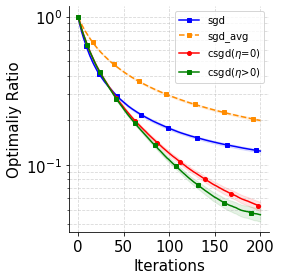

In [11]:
tab = np.arange(N+1)
fig,ax = plt.subplots(figsize=(4,4))
# SGD curves
plt.plot((mean_sgd-loss_opt)/(mean_sgd[0]-loss_opt),
         color='b',label='sgd',
         linestyle='-',marker='s',markevery=0.1,ms=4)
plt.fill_between(tab,
                 (mean_sgd-loss_opt-std_sgd)/(mean_sgd[0]-loss_opt),
                 (mean_sgd-loss_opt+std_sgd)/(mean_sgd[0]-loss_opt),
                  color='b',alpha=0.1)
# Polyak-averaging curves
plt.plot((mean_sgd_avg-loss_opt)/(mean_sgd_avg[0]-loss_opt),
         color='darkorange',label='sgd_avg',
         linestyle='--',marker='s',markevery=0.1,ms=4)
plt.fill_between(tab,
                 (mean_sgd_avg-loss_opt-std_sgd_avg)/(mean_sgd_avg[0]-loss_opt),
                 (mean_sgd_avg-loss_opt+std_sgd_avg)/(mean_sgd_avg[0]-loss_opt),
                  color='darkorange',alpha=0.1)
# C-SGD equal curves
plt.plot((mean_equal-loss_opt)/(mean_equal[0]-loss_opt),
         color='red',label=r'csgd($\eta$=0)',
         linestyle='-',marker='o',markevery=0.1,ms=4)
plt.fill_between(tab,
                 (mean_equal-loss_opt-std_equal)/(mean_equal[0]-loss_opt),
                 (mean_equal-loss_opt+std_equal)/(mean_equal[0]-loss_opt),
                  color='red',alpha=0.1)
# C-SGD weighted curves
plt.plot((mean_weighted-loss_opt)/(mean_weighted[0]-loss_opt),
         color='green',label=r'csgd($\eta$>0)',
         linestyle='-',marker='s',markevery=0.1,ms=4)
plt.fill_between(tab,
                 (mean_weighted-loss_opt-std_weighted)/(mean_weighted[0]-loss_opt),
                 (mean_weighted-loss_opt+std_weighted)/(mean_weighted[0]-loss_opt),
                  color='green',alpha=0.1)
# Graphics and Layout
plt.yscale('log')
plt.ylabel(r'Optimaliy Ratio',fontsize=15)
plt.xlabel('Iterations',fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.legend(loc='upper right',fontsize=10)
plt.grid(linestyle='--',which='both',alpha=0.5)
plt.tight_layout()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Uncomment to save figure
#plt.savefig('mushroom.pdf',bbox_inches='tight',transparent=True,pad_inches=0)
#plt.savefig('phishing.pdf',bbox_inches='tight',transparent=True,pad_inches=0)
plt.show()